# **Data Loading**

In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set display options for better readability
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

# Load the dataset
data_path = r"C:\Users\savan\Desktop\jupyter\customer_feedback_satisfaction.csv"
df = pd.read_csv("customer_feedback_satisfaction.csv")

# Display the first five rows
print("First Five Rows of the Dataset:")
display(df.head())

First Five Rows of the Dataset:


,CustomerID,Age,Gender,Country,Income,ProductQuality,ServiceQuality,PurchaseFrequency,FeedbackScore,LoyaltyLevel,SatisfactionScore
0,1,56,Male,UK,83094,5,8,5,Low,Bronze,100.0
1,2,69,Male,UK,86860,10,2,8,Medium,Gold,100.0
2,3,46,Female,USA,60173,8,10,18,Medium,Silver,100.0
3,4,32,Female,UK,73884,7,10,16,Low,Gold,100.0
4,5,60,Male,UK,97546,6,4,13,Low,Bronze,82.0


# **Data Exploration**

In [3]:
# Get the shape of the dataset
print(f"Dataset contains {df.shape[0]} rows and {df.shape[1]} columns.\n")

# Display column names
print("Column Names:")
print(df.columns.tolist(), "\n")

# Display data types
print("Data Types:")
print(df.dtypes, "\n")

# Check for missing values
missing_values = df.isnull().sum()
print("Missing Values in Each Column:")
print(missing_values[missing_values > 0], "\n")

Dataset contains 38444 rows and 11 columns.

Column Names:
['CustomerID', 'Age', 'Gender', 'Country', 'Income', 'ProductQuality', 'ServiceQuality', 'PurchaseFrequency', 'FeedbackScore', 'LoyaltyLevel', 'SatisfactionScore'] 

Data Types:
CustomerID             int64
Age                    int64
Gender                object
Country               object
Income                 int64
ProductQuality         int64
ServiceQuality         int64
PurchaseFrequency      int64
FeedbackScore         object
LoyaltyLevel          object
SatisfactionScore    float64
dtype: object 

Missing Values in Each Column:
Series([], dtype: int64) 



In [4]:
# Display statistical summary for numerical columns
print("Statistical Summary (Numerical Features):")
display(df.describe())

# Identify and display categorical columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"\nCategorical Columns: {categorical_cols}\n")

# Display value counts for each categorical column
for col in categorical_cols:
    print(f"Value Counts for '{col}':")
    print(df[col].value_counts(dropna=False), "\n")


Statistical Summary (Numerical Features):


,CustomerID,Age,Income,ProductQuality,ServiceQuality,PurchaseFrequency,SatisfactionScore
count,38444.000000,38444.000000,38444.000000,38444.000000,38444.000000,38444.000000,38444.000000
mean,19222.500000,43.496853,75076.619238,5.494746,5.492769,10.453881,85.276409
std,11097.971211,14.972748,25975.752966,2.873192,2.875812,5.765621,16.898577
min,1.000000,18.000000,30001.000000,1.000000,1.000000,1.000000,4.280000
25%,9611.750000,31.000000,52624.500000,3.000000,3.000000,5.000000,74.470000
50%,19222.500000,43.000000,75236.000000,5.000000,5.000000,10.000000,91.270000
75%,28833.250000,56.000000,97606.750000,8.000000,8.000000,15.000000,100.000000
max,38444.000000,69.000000,119999.000000,10.000000,10.000000,20.000000,100.000000



Categorical Columns: ['Gender', 'Country', 'FeedbackScore', 'LoyaltyLevel']

Value Counts for 'Gender':
Gender
Female    19294
Male      19150
Name: count, dtype: int64 

Value Counts for 'Country':
Country
USA        7762
France     7707
Canada     7693
Germany    7654
UK         7628
Name: count, dtype: int64 

Value Counts for 'FeedbackScore':
FeedbackScore
High      12918
Low       12784
Medium    12742
Name: count, dtype: int64 

Value Counts for 'LoyaltyLevel':
LoyaltyLevel
Gold      12912
Bronze    12804
Silver    12728
Name: count, dtype: int64 



# **Data Preprocessing**

In [9]:
# Drop 'CustomerID' as it's a unique identifier and not useful for modeling
if 'CustomerID' in df.columns:
    df.drop('CustomerID', axis=1, inplace=True)
else:
    print("'CustomerID' column not found!")

# Initialize LabelEncoder for binary categorical variables
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

# Encode 'Gender' (binary)
if 'Gender' in df.columns:
    print("Unique values in 'Gender':", df['Gender'].unique())
    df['Gender'] = le.fit_transform(df['Gender'])
else:
    print("'Gender' column not found!")

# Encode 'FeedbackScore' and 'LoyaltyLevel' using One-Hot Encoding
if 'FeedbackScore' in df.columns and 'LoyaltyLevel' in df.columns:
    # Ensure categorical dtype
    df['FeedbackScore'] = df['FeedbackScore'].astype('category')
    df['LoyaltyLevel'] = df['LoyaltyLevel'].astype('category')
    
    df = pd.get_dummies(df, columns=['FeedbackScore', 'LoyaltyLevel'], drop_first=True)
else:
    print("'FeedbackScore' or 'LoyaltyLevel' columns not found!")

# Encode 'Country' using One-Hot Encoding (if not too many unique categories)
if 'Country' in df.columns:
    if df['Country'].nunique() > 50:
        print(f"Warning: 'Country' has {df['Country'].nunique()} unique categories, which might lead to high-dimensional data.")
    else:
        df = pd.get_dummies(df, columns=['Country'], drop_first=True)
else:
    print("'Country' column not found!")

# Verify the encoding
print("Data after Encoding:")
display(df.head())


'CustomerID' column not found!
Unique values in 'Gender': ['Male' 'Female']
Data after Encoding:


,Age,Gender,Income,ProductQuality,ServiceQuality,PurchaseFrequency,SatisfactionScore,FeedbackScore_Low,FeedbackScore_Medium,LoyaltyLevel_Gold,LoyaltyLevel_Silver,Country_France,Country_Germany,Country_UK,Country_USA
0,56,1,83094,5,8,5,100.0,True,False,False,False,False,False,True,False
1,69,1,86860,10,2,8,100.0,False,True,True,False,False,False,True,False
2,46,0,60173,8,10,18,100.0,False,True,False,True,False,False,False,True
3,32,0,73884,7,10,16,100.0,True,False,True,False,False,False,True,False
4,60,1,97546,6,4,13,82.0,True,False,False,False,False,False,True,False


In [10]:
# Check data types after encoding
print("\nData Types after Encoding:")
print(df.dtypes)

# Feature Scaling (Optional but recommended for certain models)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
numerical_cols = ['Age', 'Income', 'ProductQuality', 'ServiceQuality', 'PurchaseFrequency']
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

# Display scaled numerical features
print("\nScaled Numerical Features:")
display(df[numerical_cols].head())


Data Types after Encoding:
Age                       int64
Gender                    int64
Income                    int64
ProductQuality            int64
ServiceQuality            int64
PurchaseFrequency         int64
SatisfactionScore       float64
FeedbackScore_Low          bool
FeedbackScore_Medium       bool
LoyaltyLevel_Gold          bool
LoyaltyLevel_Silver        bool
Country_France             bool
Country_Germany            bool
Country_UK                 bool
Country_USA                bool
dtype: object

Scaled Numerical Features:


,Age,Income,ProductQuality,ServiceQuality,PurchaseFrequency
0,0.835071,0.308653,-0.172196,0.871845,-0.945943
1,1.703326,0.453636,1.568051,-1.214549,-0.425611
2,0.167182,-0.573759,0.871952,1.567310,1.308830
3,-0.767862,-0.045913,0.523903,1.567310,0.961942
4,1.102227,0.865025,0.175854,-0.519084,0.441609


# **Exploratory Data Analysis (EDA)**

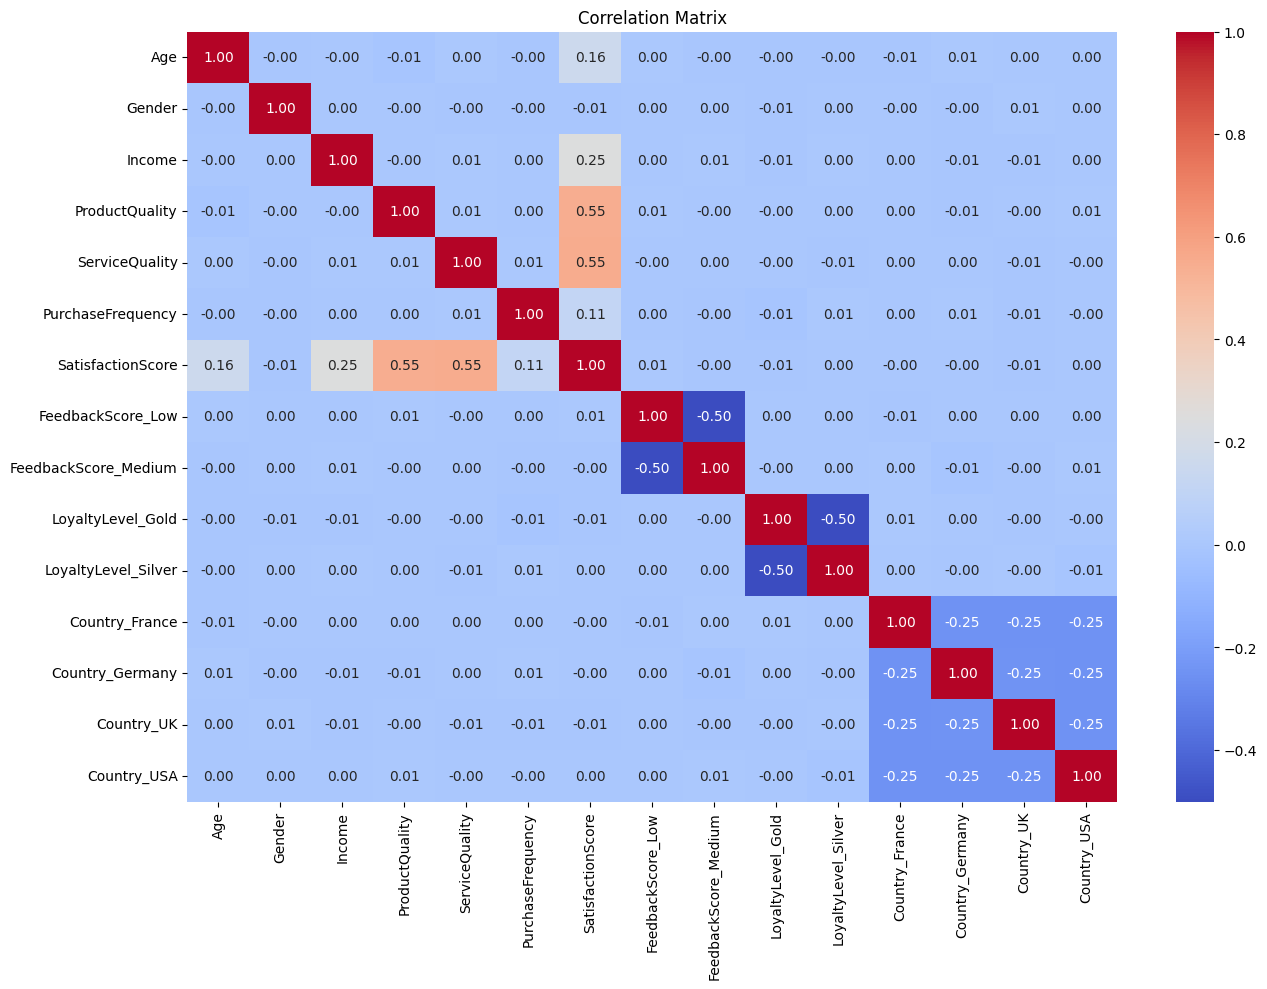

In [11]:
# Correlation Matrix
plt.figure(figsize=(15,10))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

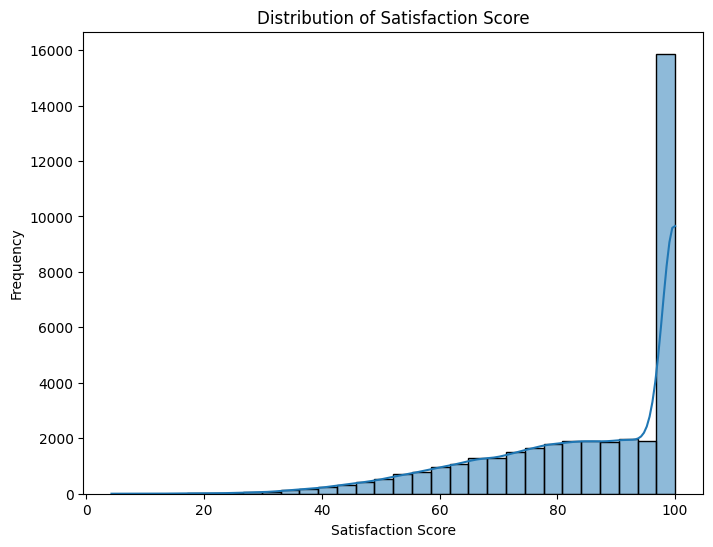

In [12]:
# Distribution of SatisfactionScore
plt.figure(figsize=(8,6))
sns.histplot(df['SatisfactionScore'], bins=30, kde=True)
plt.title('Distribution of Satisfaction Score')
plt.xlabel('Satisfaction Score')
plt.ylabel('Frequency')
plt.show()

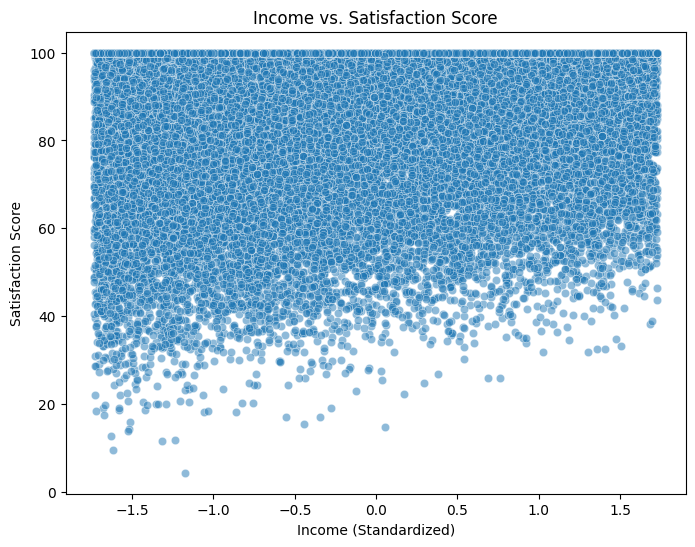

In [13]:
# Relationship between Income and SatisfactionScore
plt.figure(figsize=(8,6))
sns.scatterplot(x='Income', y='SatisfactionScore', data=df, alpha=0.5)
plt.title('Income vs. Satisfaction Score')
plt.xlabel('Income (Standardized)')
plt.ylabel('Satisfaction Score')
plt.show()

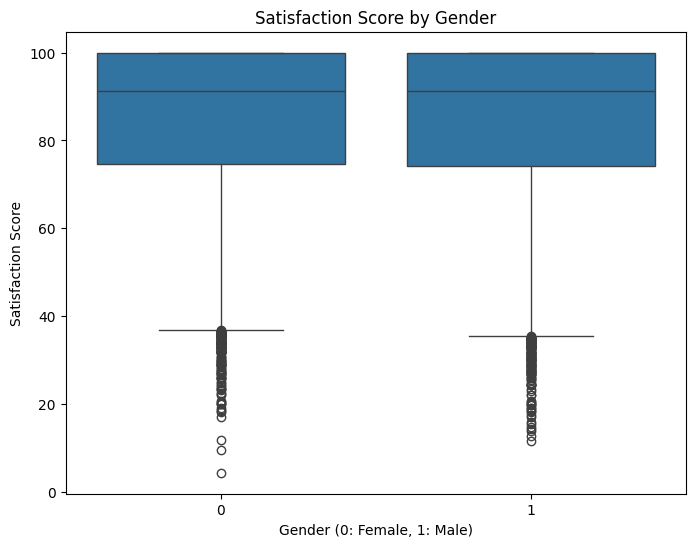

In [14]:
# Boxplot of SatisfactionScore by Gender
plt.figure(figsize=(8,6))
sns.boxplot(x='Gender', y='SatisfactionScore', data=df)
plt.title('Satisfaction Score by Gender')
plt.xlabel('Gender (0: Female, 1: Male)')
plt.ylabel('Satisfaction Score')
plt.show()

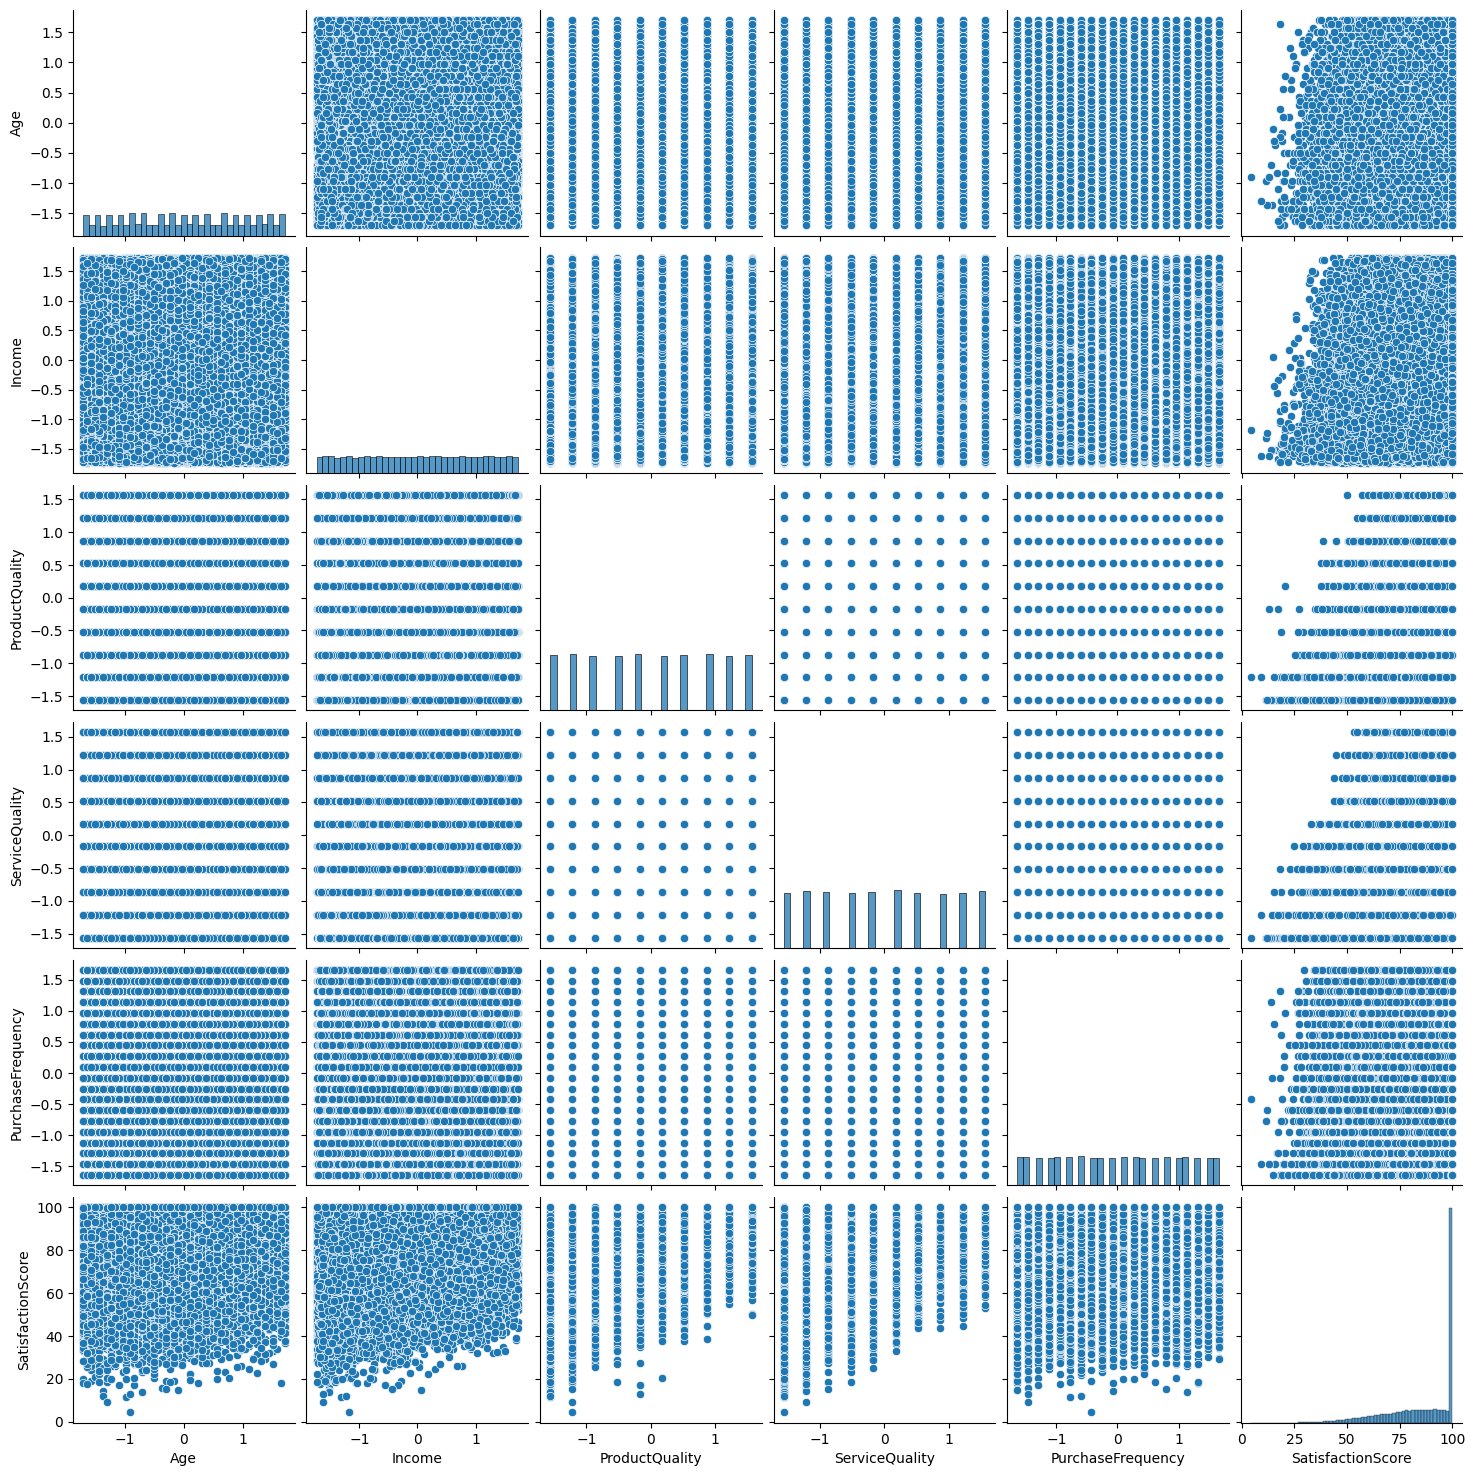

In [19]:
# Pairplot for selected features
selected_features = ['Age', 'Income', 'ProductQuality', 'ServiceQuality', 'PurchaseFrequency', 'SatisfactionScore']
sns.pairplot(df[selected_features])
plt.show()

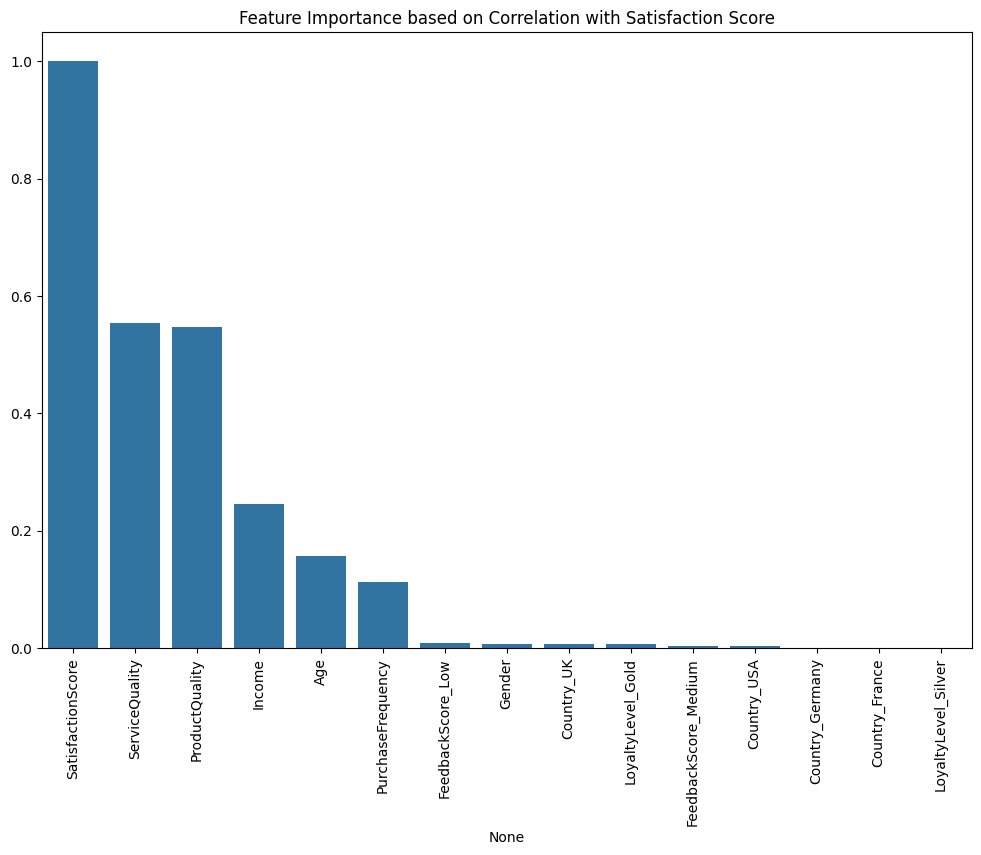

In [18]:
# Feature Importance using Correlation
plt.figure(figsize=(12,8))
sns.barplot(x=corr['SatisfactionScore'].abs().sort_values(ascending=False).index, 
            y=corr['SatisfactionScore'].abs().sort_values(ascending=False).values)
plt.xticks(rotation=90)
plt.title('Feature Importance based on Correlation with Satisfaction Score')
plt.show()

# **Feature Engineering**

In [20]:
# Creating Interaction Terms (if relevant)
df['Income_ProductQuality'] = df['Income'] * df['ProductQuality']
df['Income_ServiceQuality'] = df['Income'] * df['ServiceQuality']

# Creating Polynomial Features (e.g., squared terms)
df['Age_Squared'] = df['Age'] ** 2
df['PurchaseFrequency_Squared'] = df['PurchaseFrequency'] ** 2

# Feature Selection based on Correlation
# Selecting features with correlation > 0.1 with the target
correlation_threshold = 0.1
relevant_features = corr['SatisfactionScore'][corr['SatisfactionScore'].abs() > correlation_threshold].index.tolist()
relevant_features.remove('SatisfactionScore')  # Remove target from features

# Reducing the dataset to relevant features
X = df[relevant_features]
y = df['SatisfactionScore']

print(f"Number of features selected: {X.shape[1]}")
print("Selected Features:")
print(X.columns.tolist())

Number of features selected: 5
Selected Features:
['Age', 'Income', 'ProductQuality', 'ServiceQuality', 'PurchaseFrequency']


# **Model Training and Evaluation**

In [21]:
# Import necessary libraries for modeling
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training Set: {X_train.shape[0]} samples")
print(f"Testing Set: {X_test.shape[0]} samples")

Training Set: 30755 samples
Testing Set: 7689 samples


 TabNet Regressor

In [5]:
import numpy as np
import pandas as pd
import os
from pytorch_tabnet.tab_model import TabNetRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import torch

# Verify dataset exists
data_path = "customer_feedback_satisfaction.csv"
if not os.path.exists(data_path):
    raise FileNotFoundError(f"❌ Error: File '{data_path}' not found!")

df = pd.read_csv(data_path)
print("✅ Dataset loaded successfully!")

# Handle missing values
df.fillna(df.median(numeric_only=True), inplace=True)

# Ensure target column exists
target = "satisfaction_score"
if target not in df.columns:
    print(f"❌ Error: Column '{target}' not found!")
    print("📌 Available columns:", df.columns.tolist())  # Debugging info
    raise ValueError("Check the dataset for correct target column name.")

# Separate features and target
X = df.drop(columns=[target])
y = df[target].astype(np.float32)  # Ensure target is float

# Convert categorical columns to numeric
cat_cols = X.select_dtypes(include=['object']).columns
X[cat_cols] = X[cat_cols].astype('category').apply(lambda x: x.cat.codes)

# Convert to NumPy
X = X.to_numpy()
y = y.to_numpy().reshape(-1, 1)  # Ensure correct shape

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Ensure train & test have same columns
X_train, X_test = pd.DataFrame(X_train), pd.DataFrame(X_test)
X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)

# Convert back to NumPy
X_train, X_test = X_train.to_numpy(), X_test.to_numpy()

print(f"✅ X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"✅ X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

# Check for CUDA availability
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"🖥️ Using device: {device}")

# Initialize TabNet Regressor
tabnet = TabNetRegressor(
    verbose=1,
    seed=42,
    n_d=16,
    n_a=16,
    n_steps=5,
    gamma=1.3,
    lambda_sparse=1e-3,
    device_name=device
)

# Train the model
tabnet.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    eval_name=['train', 'valid'],
    eval_metric=['rmse'],
    max_epochs=300,
    patience=30,
    batch_size=512,
    virtual_batch_size=128,
    num_workers=0,
    drop_last=False
)

# Make predictions
tabnet_pred = tabnet.predict(X_test)

# Evaluate model
rmse_tabnet = np.sqrt(mean_squared_error(y_test, tabnet_pred))
r2_tabnet = r2_score(y_test, tabnet_pred)

print(f"✅ TabNet Regressor - RMSE: {rmse_tabnet:.4f}, R²: {r2_tabnet:.4f}")


✅ Dataset loaded successfully!
❌ Error: Column 'satisfaction_score' not found!
📌 Available columns: ['CustomerID', 'Age', 'Gender', 'Country', 'Income', 'ProductQuality', 'ServiceQuality', 'PurchaseFrequency', 'FeedbackScore', 'LoyaltyLevel', 'SatisfactionScore']


ValueError: Check the dataset for correct target column name.

# **Neural Network Regressor**

In [ ]:
# Import necessary libraries
pip install tensorflow


import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define the improved model
def create_mlp(input_dim):
    model = Sequential()
    model.add(Dense(128, input_dim=input_dim, activation='relu'))
    model.add(BatchNormalization())  # New: Batch Normalization
    model.add(Dropout(0.3))
    
    model.add(Dense(64, activation='relu'))
    model.add(BatchNormalization())  # New: Batch Normalization
    model.add(Dropout(0.2))
    
    model.add(Dense(32, activation='relu'))
    model.add(Dense(1, activation='linear'))  # Output layer for regression
    
    return model

# Create the model
mlp_model = create_mlp(X_train_scaled.shape[1])

# Compile the model
mlp_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Define callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=50, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=10, min_lr=1e-5)

# Train the model
history = mlp_model.fit(
    X_train_scaled, y_train,
    epochs=200,
    batch_size=256,
    validation_data=(X_test_scaled, y_test),
    callbacks=[early_stop, reduce_lr],  # Using ReduceLROnPlateau
    verbose=1
)

# Make predictions
mlp_pred = mlp_model.predict(X_test_scaled).flatten()

# Evaluate the model
rmse_mlp = np.sqrt(mean_squared_error(y_test, mlp_pred))
r2_mlp = r2_score(y_test, mlp_pred)
mape_mlp = mean_absolute_percentage_error(y_test, mlp_pred)  # New: MAPE

print(f"Neural Network Regressor - RMSE: {rmse_mlp:.4f}, R²: {r2_mlp:.4f}, MAPE: {mape_mlp:.2%}")


In [14]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Check if required variables exist
required_vars = ['rmse_tabnet', 'rmse_mlp', 'r2_tabnet', 'r2_mlp']
missing_vars = [var for var in required_vars if var not in globals()]
if missing_vars:
    raise ValueError(f"Missing required variables: {', '.join(missing_vars)}")

# Define model names and performance metrics
models = ['TabNet Regressor', 'Neural Network Regressor']
rmse = [rmse_tabnet, rmse_mlp]  # Replace with actual RMSE values
r2 = [r2_tabnet, r2_mlp]        # Replace with actual R² values

# Create a DataFrame from the lists
model_performance = pd.DataFrame({'Model': models, 'RMSE': rmse, 'R2': r2})

# Display the DataFrame (optional)
print(model_performance)

# Set Seaborn style
sns.set(style="whitegrid")

# Initialize the matplotlib figure
plt.figure(figsize=(14, 6))

# Plot RMSE for each model
plt.subplot(1, 2, 1)
ax1 = sns.barplot(x='Model', y='RMSE', data=model_performance, palette='viridis')
plt.title('Model Comparison: RMSE', fontsize=14, fontweight='bold')
plt.ylabel('Root Mean Squared Error', fontsize=12)
plt.xlabel('Model', fontsize=12)
plt.ylim(0, model_performance['RMSE'].max() + 2)

# Annotate RMSE values
for p in ax1.patches:
    ax1.annotate(f"{p.get_height():.4f}", (p.get_x() + p.get_width() / 2, p.get_height() + 0.2),
                 ha='center', fontsize=11, fontweight='bold', color='black')

# Plot R² for each model
plt.subplot(1, 2, 2)
ax2 = sns.barplot(x='Model', y='R2', data=model_performance, palette='magma')
plt.title('Model Comparison: R² Score', fontsize=14, fontweight='bold')
plt.ylabel('R² Score', fontsize=12)
plt.xlabel('Model', fontsize=12)

# Dynamically set R² limits to avoid cutting off negative values
plt.ylim(min(0, model_performance['R2'].min() - 0.05), 1)

# Annotate R² values
for p in ax2.patches:
    ax2.annotate(f"{p.get_height():.4f}", (p.get_x() + p.get_width() / 2, p.get_height() + 0.02),
                 ha='center', fontsize=11, fontweight='bold', color='black')

# Adjust layout for better spacing
plt.tight_layout()

# Show the plots
plt.show()


ValueError: Missing required variables: rmse_tabnet, rmse_mlp, r2_tabnet, r2_mlp

In [ ]:
# Import necessary libraries
!pip install catboost




from catboost import CatBoostRegressor, Pool
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from nltk.sentiment import SentimentIntensityAnalyzer
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import nltk

# Ensure VADER is available
nltk.download('vader_lexicon')

# Load dataset
data_path = "customer_feedback_satisfaction.csv"
df = pd.read_csv(data_path)

# Handle missing values (Forward Fill + Backward Fill for better handling)
df.fillna(method='ffill', inplace=True)
df.fillna(method='bfill', inplace=True)

# Identify categorical and numerical columns
categorical_features = df.select_dtypes(include=['object']).columns.tolist()
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Separate features and target variable (assuming 'satisfaction_score' is the target)
target = 'satisfaction_score'
X = df.drop(columns=[target])
y = df[target]

# Standardize only numerical features (CatBoost handles categorical features automatically)
scaler = StandardScaler()
X[numerical_features] = scaler.fit_transform(X[numerical_features])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Convert to CatBoost Pool format
train_pool = Pool(X_train, y_train, cat_features=categorical_features)
test_pool = Pool(X_test, y_test, cat_features=categorical_features)

# Initialize CatBoost Regressor with tuned hyperparameters
model = CatBoostRegressor(iterations=1000, learning_rate=0.05, depth=8, verbose=100)

# Train the model
model.fit(train_pool, eval_set=test_pool, early_stopping_rounds=50)

# Predictions
y_pred = model.predict(X_test)

# Evaluation Metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"📊 RMSE: {rmse:.4f}")
print(f"📊 MAE: {mae:.4f}")
print(f"📊 R² Score: {r2:.4f}")

# Sentiment Analysis using VADER
sia = SentimentIntensityAnalyzer()
if 'feedback_text' in df.columns:  # Check if feedback column exists
    df['sentiment_score'] = df['feedback_text'].apply(lambda text: sia.polarity_scores(str(text))['compound'])
    df['sentiment_label'] = df['sentiment_score'].apply(lambda score: 'Positive' if score > 0.05 else ('Negative' if score < -0.05 else 'Neutral'))
    
    # Plot sentiment distribution
    plt.figure(figsize=(8, 5))
    sns.countplot(x='sentiment_label', data=df, palette='coolwarm')
    plt.title("Customer Feedback Sentiment Distribution")
    plt.xlabel("Sentiment")
    plt.ylabel("Count")
    plt.show()

    # Correlation between sentiment and satisfaction
    plt.figure(figsize=(8, 5))
    sns.scatterplot(x=df['sentiment_score'], y=df['satisfaction_score'], alpha=0.6)
    plt.title("Sentiment Score vs. Satisfaction Score")
    plt.xlabel("Sentiment Score")
    plt.ylabel("Satisfaction Score")
    plt.show()
    
else:
    print("❌ No textual feedback column found for sentiment analysis.")
